# Introduction to Agentic AI with LangGraph

## Learning Objectives

By the end of this notebook, you will:
1. Understand how **LangGraph** formalizes the ReAct pattern into explicit graphs
2. Learn core concepts: **State**, **Nodes**, **Edges**, and **Conditional Routing**
3. Build a working **Research Assistant Agent** with tools
4. Visualize agent execution flow

---

## Prerequisites

This notebook builds on concepts from:
- `03_ReAct_Agent.ipynb` - ReAct pattern from scratch
- `01_function_calling_openai.ipynb` - Tool/function calling
- `03_function_calling_langchain.ipynb` - LangChain agents

## Step 0: Install Dependencies

LangGraph is a library for building stateful, multi-step AI applications with LLMs.

In [12]:
!uv pip install -q langgraph langchain langchain-openai tavily-python python-dotenv

## Step 1: Setup & Configuration

In [2]:
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# For Colab: uncomment and add your keys
# os.environ["OPENAI_API_KEY"] = "your-key-here"
# os.environ["TAVILY_API_KEY"] = "your-key-here"  # Get free key at tavily.com

if os.getenv("OPENAI_API_KEY"):
    print("✅ OPENAI_API_KEY loaded")
else:
    print("⚠️ OPENAI_API_KEY not found")

if os.getenv("TAVILY_API_KEY"):
    print("✅ TAVILY_API_KEY loaded")
else:
    print("⚠️ TAVILY_API_KEY not found (web search will use mock data)")

✅ OPENAI_API_KEY loaded
✅ TAVILY_API_KEY loaded


---

## Part 1: From ReAct to LangGraph

### Recap: The ReAct Loop

In the `03_ReAct_Agent.ipynb` notebook, you built a ReAct agent from scratch. The pattern was:

```
Thought → Action → PAUSE → Observation → Thought → ... → Answer
```

You implemented this with:
1. A prompt that instructed the LLM to output `Thought:`, `Action:`, etc.
2. Python code that parsed the output and executed tools
3. A loop that continued until `Answer:` was found

### The Problem with Prompt-Based Agents

While this works, there are challenges:

| Issue | Description |
|-------|-------------|
| **Fragile Parsing** | The LLM might not follow the exact format |
| **Hidden Control Flow** | The logic is embedded in prompts, hard to debug |
| **No State Management** | Difficult to persist conversations or checkpoint progress |
| **Limited Composability** | Hard to build complex multi-agent systems |

### The Solution: LangGraph

**LangGraph** solves these problems by making the agent loop **explicit as a graph**:

```
┌─────────────────────────────────────────────────────────┐
│                                                         │
│    START → [Agent] → (should_continue?) → [Tools] ──┐   │
│                │                                    │   │
│                │ (if done)                          │   │
│                ▼                                    │   │
│               END ◄─────────────────────────────────┘   │
│                                                         │
└─────────────────────────────────────────────────────────┘
```

**Key insight**: The graph *is* the program. The LLM is just one of the nodes.

---

## Part 2: Core LangGraph Concepts

Before building our agent, let's understand the core concepts:

### 1. State
A shared data structure that flows through the graph. Every node can read and modify it.

```python
# Example: MessagesState holds the conversation history
from langgraph.graph import MessagesState
```

### 2. Nodes
Functions that process the state. Each node receives the current state and returns updates.

```python
def my_node(state: MessagesState):
    # Do something with state
    return {"messages": [new_message]}
```

### 3. Edges
Connections between nodes. Can be:
- **Normal edges**: Always go from A → B
- **Conditional edges**: Router function decides where to go next

### 4. Graph Compilation
The graph is compiled into an executable that manages state, routing, and execution.

---

## Part 3: Building a Research Assistant Agent

Let's build a practical agent that can:
1. **Search the web** for current information
2. **Perform calculations** for math questions
3. **Get the current time** for time-related queries

### Step 3.1: Define Tools

Tools are functions the agent can call. We use LangChain's `@tool` decorator.

In [3]:
from langchain_core.tools import tool
from datetime import datetime
import os

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression. Use this for any math calculations.
    
    Args:
        expression: A mathematical expression like '2 + 2' or '15 * 7'
    """
    try:
        # Safety: only allow basic math operations
        allowed = set('0123456789+-*/.() ')
        if not all(c in allowed for c in expression):
            return "Error: Invalid characters in expression"
        result = eval(expression)
        return f"Result: {result}"
    except Exception as e:
        return f"Error: {str(e)}"

@tool
def get_current_time() -> str:
    """Get the current date and time. Use this when asked about today's date or current time."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
def web_search(query: str) -> str:
    """Search the web for current information. Use this for questions about recent events, 
    current facts, or anything that might have changed since your training.
    
    Args:
        query: The search query
    """
    # Try to use Tavily if available, otherwise use mock data
    if os.getenv("TAVILY_API_KEY"):
        from tavily import TavilyClient
        client = TavilyClient()
        response = client.search(query, max_results=3)
        results = []
        for r in response.get("results", []):
            results.append(f"- {r.get('title', 'No title')}: {r.get('content', 'No content')[:200]}...")
        return "\n".join(results) if results else "No results found."
    else:
        # Mock response for demo purposes
        return f"[Mock Search Result for '{query}']\n" + \
               f"This is simulated search data. To get real results, add TAVILY_API_KEY to your environment.\n" + \
               f"Tip: Get a free API key at https://tavily.com"

# Collect all tools
tools = [calculate, get_current_time, web_search]

print("✅ Tools defined:")
for t in tools:
    print(f"   - {t.name}: {t.description[:60]}...")

✅ Tools defined:
   - calculate: Evaluate a mathematical expression. Use this for any math ca...
   - get_current_time: Get the current date and time. Use this when asked about tod...
   - web_search: Search the web for current information. Use this for questio...


### Step 3.2: Initialize the LLM with Tools

We bind our tools to the LLM so it knows what's available.

In [4]:
from langchain_openai import ChatOpenAI

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Bind tools to the LLM
# This tells the LLM what tools are available and their schemas
llm_with_tools = llm.bind_tools(tools)

print("✅ LLM initialized and tools bound")

✅ LLM initialized and tools bound


### Step 3.3: Build the Graph

Now we construct our agent as a graph with:
- An **agent node** that calls the LLM
- A **tools node** that executes tool calls
- **Conditional edges** that route based on whether tools were called

In [5]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

# Step 1: Define the agent node
def call_agent(state: MessagesState):
    """
    The agent node: calls the LLM with the current messages.
    The LLM decides whether to respond directly or call a tool.
    """
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Step 2: Define the routing function
def should_continue(state: MessagesState):
    """
    Conditional edge function: decides where to go next.
    - If the LLM called tools → go to 'tools' node
    - If the LLM responded directly → go to END
    """
    last_message = state["messages"][-1]
    
    # Check if there are tool calls in the response
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    else:
        return END

# Step 3: Create the ToolNode (built-in helper)
tool_node = ToolNode(tools)

# Step 4: Build the graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("agent", call_agent)
workflow.add_node("tools", tool_node)

# Add edges
workflow.add_edge(START, "agent")  # Start by calling the agent
workflow.add_conditional_edges("agent", should_continue)  # Agent decides next step
workflow.add_edge("tools", "agent")  # After tools, go back to agent

# Compile the graph
agent = workflow.compile()

print("✅ Agent graph compiled!")

✅ Agent graph compiled!


### Step 3.4: Visualize the Graph

One of LangGraph's powerful features is the ability to visualize the agent's structure.

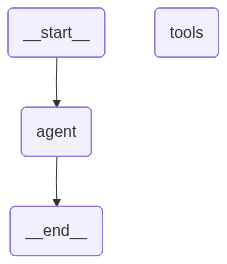

In [6]:
from IPython.display import Image, display

try:
    # Generate and display the graph visualization
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    # If visualization fails (missing dependencies), show text version
    print("Graph structure:")
    print(agent.get_graph().draw_mermaid())

---

## Part 4: Testing the Agent

Let's test our agent with various queries to see how it uses different tools.

In [7]:
from langchain_core.messages import HumanMessage

def chat(user_input: str):
    """Helper function to chat with our agent."""
    print(f"\n{'='*60}")
    print(f"🧑 User: {user_input}")
    print(f"{'='*60}")
    
    # Invoke the agent
    result = agent.invoke({"messages": [HumanMessage(content=user_input)]})
    
    # Print the conversation flow
    for msg in result["messages"]:
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"\n🔧 Tool Call: {tc['name']}({tc['args']})")
        elif msg.type == "tool":
            print(f"📥 Tool Result: {msg.content[:200]}..." if len(msg.content) > 200 else f"📥 Tool Result: {msg.content}")
        elif msg.type == "ai" and msg.content:
            print(f"\n🤖 Assistant: {msg.content}")
    
    return result

In [8]:
# Test 1: Simple question (no tools needed)
chat("What is the capital of France?")


🧑 User: What is the capital of France?

🤖 Assistant: The capital of France is Paris.


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='a1210337-a71f-4109-a3c1-044d2c913ff5'),
  AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 153, 'total_tokens': 161, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-ClfkYRNeHWxfDaBXIXcP6OV16EGdF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b0eaf-6aee-70e2-9496-157d4372d41a-0', usage_metadata={'input_tokens': 153, 'output_tokens': 8, 'total_tokens': 161, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio'

In [9]:
# Test 2: Math question (uses calculate tool)
chat("What is 15% of 847?")


🧑 User: What is 15% of 847?

🔧 Tool Call: calculate({'expression': '0.15 * 847'})
📥 Tool Result: Result: 127.05

🤖 Assistant: 15% of 847 is 127.05.


{'messages': [HumanMessage(content='What is 15% of 847?', additional_kwargs={}, response_metadata={}, id='50681dd8-538f-4dec-b12b-9f22e5439c25'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 155, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-ClfkpMC8ujIYhnO9rl78lbwQM1ZHq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b0eaf-b024-7d72-98ea-21f00f5bed28-0', tool_calls=[{'name': 'calculate', 'args': {'expression': '0.15 * 847'}, 'id': 'call_cDBLJoks7hk6sglhUeLARtlv', 'type': 'tool_call'}], usage_metadata={'input_tokens': 155, 'output_tokens': 18, 'total_

In [10]:
# Test 3: Time question (uses get_current_time tool)
chat("What is today's date and time?")


🧑 User: What is today's date and time?

🔧 Tool Call: get_current_time({})
📥 Tool Result: 2025-12-11 21:32:49

🤖 Assistant: Today's date is December 11, 2025, and the current time is 21:32:49.


{'messages': [HumanMessage(content="What is today's date and time?", additional_kwargs={}, response_metadata={}, id='7e660246-1421-4b19-9e72-e8ff9b33bae1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 153, 'total_tokens': 164, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-Clfl2X0SVypSPsoNp6GoZzcSJiEyW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b0eaf-e945-7332-b358-3eafcf2b4a83-0', tool_calls=[{'name': 'get_current_time', 'args': {}, 'id': 'call_sCFxNyaJOtJQ9B5OhAWEBDFG', 'type': 'tool_call'}], usage_metadata={'input_tokens': 153, 'output_tokens': 11, 'total_tokens':

In [13]:
# Test 4: Research question (uses web_search tool)
chat("What are the latest developments in AI agents?")


🧑 User: What are the latest developments in AI agents?

🔧 Tool Call: web_search({'query': 'latest developments in AI agents 2023'})
📥 Tool Result: - The Rise of AI Agents: Redefining Automation and Productivity in 2025: AI agents are transforming business operations in 2025, automating workflows, enhancing efficiency, and redefining productivity...

🤖 Assistant: Recent developments in AI agents include:

1. **Autonomous AI Agents**: In 2023, companies like OpenAI, Anthropic, and Microsoft have introduced the first generation of autonomous AI agents. These agents are capable of managing tasks independently, enhancing productivity and efficiency in various business operations.

2. **Task Management Capabilities**: The new AI agents are designed to handle both repetitive and complex tasks, which includes areas like IT troubleshooting and workflow optimization. This shift is expected to redefine how businesses operate and improve overall productivity.

3. **Future Trends**: Looking ahead,

{'messages': [HumanMessage(content='What are the latest developments in AI agents?', additional_kwargs={}, response_metadata={}, id='b01b55a5-024f-478c-a815-6ee9eb00bc34'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 155, 'total_tokens': 176, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-ClflXRqecAqS2757nhqFMOdwiBa87', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b0eb0-5cc4-7ff2-b5fb-c1536b7b03cb-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'latest developments in AI agents 2023'}, 'id': 'call_Ud61uH4r6gWMj91PhQPdZhsN', 'type': 'tool_call'}], usage_metadata=

In [14]:
# Test 5: Multi-step question (may use multiple tools)
chat("What's the current time? Also, if I invest $1000 at 7% annual interest, how much will I have after 5 years with compound interest?")


🧑 User: What's the current time? Also, if I invest $1000 at 7% annual interest, how much will I have after 5 years with compound interest?

🔧 Tool Call: get_current_time({})

🔧 Tool Call: calculate({'expression': '1000 * (1 + 0.07) ^ 5'})
📥 Tool Result: 2025-12-11 21:33:49
📥 Tool Result: Error: Invalid characters in expression

🔧 Tool Call: calculate({'expression': '1000 * (1 + 0.07) ** 5'})
📥 Tool Result: Result: 1402.5517307000005

🔧 Tool Call: get_current_time({})
📥 Tool Result: 2025-12-11 21:33:52

🤖 Assistant: The current time is **21:33:52** on **December 11, 2025**. 

If you invest $1000 at a 7% annual interest rate, you will have approximately **$1402.55** after 5 years with compound interest.


{'messages': [HumanMessage(content="What's the current time? Also, if I invest $1000 at 7% annual interest, how much will I have after 5 years with compound interest?", additional_kwargs={}, response_metadata={}, id='c4054fa3-a42f-4462-be00-902842bf260f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 179, 'total_tokens': 233, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_aa07c96156', 'id': 'chatcmpl-Clfm0DzRQ73pVseLnsXjPjGTkzCct', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b0eb0-d16a-7d10-94d8-22a48cc113e7-0', tool_calls=[{'name': 'get_current_time', 'args': {}, 'id': 'call_LNEV6IYr9tXWHC1L0AaVv3K

---

## Part 5: Understanding the Agent Loop

Let's trace through what happens when we ask a question:

```
1. User asks: "What is 15% of 847?"
   │
   ▼
2. START → Agent Node
   - LLM receives the question
   - LLM decides to call `calculate` tool with "847 * 0.15"
   │
   ▼
3. should_continue() sees tool_calls → goes to Tools Node
   - ToolNode executes calculate("847 * 0.15")
   - Returns "Result: 127.05"
   │
   ▼
4. Tools → Agent Node (loop back)
   - LLM sees the tool result
   - LLM generates final answer: "15% of 847 is 127.05"
   │
   ▼
5. should_continue() sees no tool_calls → goes to END
```

This is exactly the **ReAct loop** you built from scratch, but now it's:
- **Explicit** in the graph structure
- **Type-safe** with proper state management
- **Observable** with built-in tracing
- **Composable** for building complex systems

---

## Part 6: Adding Memory with Checkpointing

One powerful feature of LangGraph is **checkpointing** - the ability to save and resume agent state. This enables:
- Conversation memory across turns
- Recovery from failures
- Time-travel debugging

In [15]:
from langgraph.checkpoint.memory import MemorySaver

# Create a memory saver (in-memory for demo)
memory = MemorySaver()

# Recompile the graph with memory
agent_with_memory = workflow.compile(checkpointer=memory)

print("✅ Agent recompiled with memory checkpointing")

✅ Agent recompiled with memory checkpointing


In [16]:
# Now we can have multi-turn conversations!
# The thread_id keeps track of the conversation
config = {"configurable": {"thread_id": "demo-thread-1"}}

# First message
result1 = agent_with_memory.invoke(
    {"messages": [HumanMessage(content="My name is Alex and I'm learning about AI agents.")]},
    config
)
print("🤖:", result1["messages"][-1].content)

🤖: Hi Alex! That's great to hear! AI agents are a fascinating topic. What specific aspects of AI agents are you interested in learning about?


In [17]:
# Second message - agent should remember the name!
result2 = agent_with_memory.invoke(
    {"messages": [HumanMessage(content="What's my name and what am I learning about?")]},
    config
)
print("🤖:", result2["messages"][-1].content)

🤖: Your name is Alex, and you're learning about AI agents.


---

## Summary: Key Takeaways

| Concept | ReAct (Manual) | LangGraph |
|---------|----------------|----------|
| **Control Flow** | Hidden in prompts | Explicit graph |
| **State** | Manual tracking | Built-in `MessagesState` |
| **Tools** | Manual parsing | `ToolNode` with validation |
| **Memory** | Custom implementation | `MemorySaver` checkpointing |
| **Debugging** | Print statements | Graph visualization & tracing |

**LangGraph = ReAct patterns + Production-ready infrastructure**

---

## 🎯 Student Challenge

Now it's your turn! Try these exercises:

### Challenge 1: Add a New Tool
Create a `wikipedia_search` tool that looks up information on Wikipedia. You can use the `wikipedia` Python package or mock the response.

```python
# Hint:
@tool
def wikipedia_search(topic: str) -> str:
    """Search Wikipedia for information on a topic."""
    # Your code here
    pass
```

### Challenge 2: Modify the Graph
Add a "summarize" node that runs after the agent generates a long response (more than 200 words). The summarize node should condense the response.

### Challenge 3: Custom State
Instead of using `MessagesState`, create a custom state that also tracks:
- Number of tool calls made
- List of topics discussed

```python
# Hint:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages

class MyCustomState(TypedDict):
    messages: Annotated[list, add_messages]
    tool_call_count: int
    topics: list[str]
```

In [ ]:
# Your solution for Challenge 1 here:



In [ ]:
# Your solution for Challenge 2 here:



In [ ]:
# Your solution for Challenge 3 here:



---

## Next Steps

In the next notebook (`02_Agentic_RAG.ipynb`), we'll apply these concepts to build an **Agentic RAG** system that:
- Decides whether retrieval is needed
- Grades document relevance
- Rewrites queries when results aren't helpful

This shows how LangGraph enables sophisticated AI applications beyond simple chatbots!